In [46]:
import pm4py
import networkx as nx

print("Loading data...")
path = "data/ocel2-p2p.json"
ocel = pm4py.read_ocel2_json(path)

Loading data...


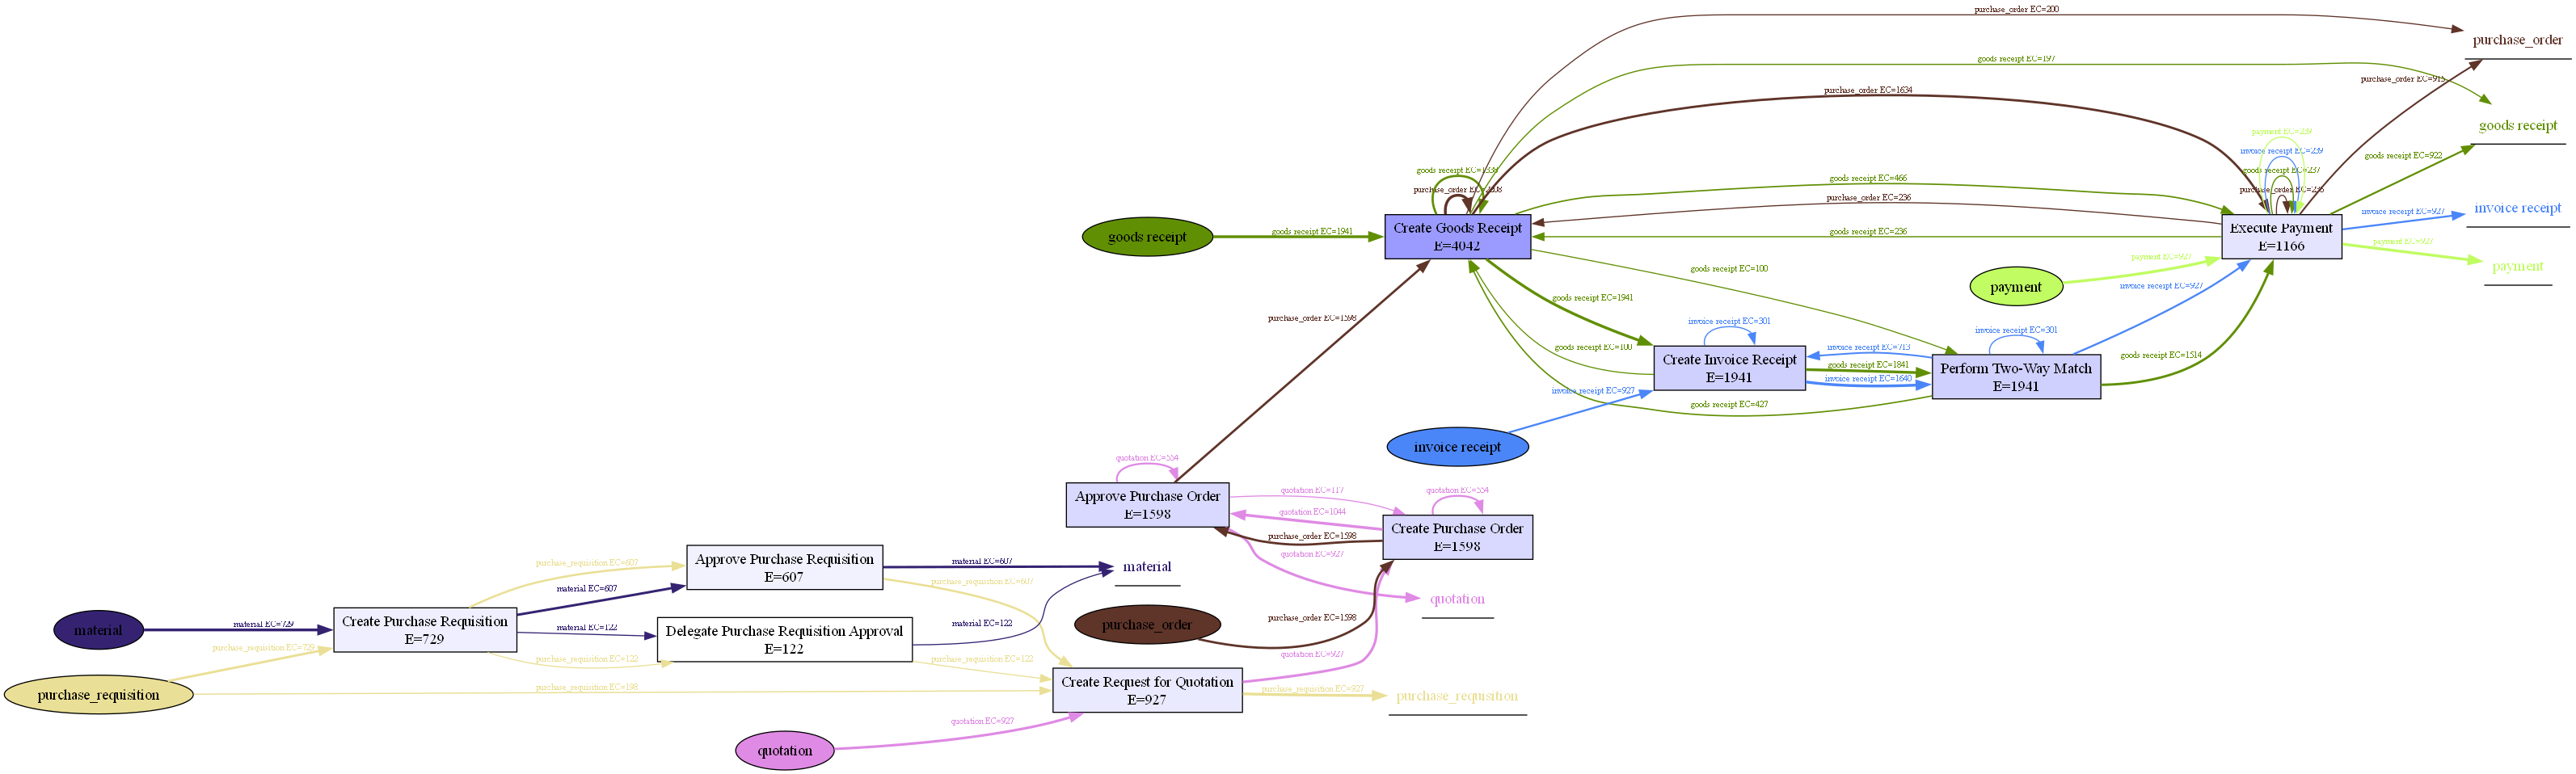

In [66]:
import statistics

ocpn = pm4py.discover_oc_petri_net(ocel)
ocdfg = pm4py.discover_ocdfg(ocel)

#print(ocpn.keys())
pm4py.view_ocdfg(ocdfg)
#pm4py.view_ocpn(ocpn)

In [67]:
def ocdfg_to_networkx_cleaned(ocdfg):
    G = nx.MultiDiGraph()
    
    # 1. ONLY add activities as nodes
    # pm4py OCDFG.activities is a dictionary or list of activity names
    for act in ocdfg.activities:
        G.add_node(act, type="activity")

    # 2. Add edges only between activities
    # The ocdfg.edges keys are (act_from, act_to, obj_type)
    for (a1, a2, obj_type), value in ocdfg.edges.items():
        # Avoid adding edges to 'None' or 'Start/End' if you want it clean
        if a1 and a2: 
            weight = len(value) if isinstance(value, set) else value
            G.add_edge(a1, a2, object_type=obj_type, weight=weight)
            
    return G

global_graph = ocdfg_to_networkx_cleaned(ocdfg)
print(f"[Global graph] {global_graph.number_of_nodes()} activity nodes, "
      f"{global_graph.number_of_edges()} DFG edges.")

AttributeError: 'dict' object has no attribute 'activities'

In [ ]:
import networkx as nx

def ocdfg_to_networkx(ocdfg):
    G = nx.MultiDiGraph()

    # Add nodes
    for act in ocdfg["activities"]:
        G.add_node(act, type="activity")

    # Add edges (nested dict version)
    for obj_type, edges in ocdfg["edges"].items():
        for a1, targets in edges.items():
            for a2, value in targets.items():

                # Handle value formats
                if isinstance(value, dict):
                    weight = value.get("count", 1)
                    performance = value.get("performance", None)
                else:
                    weight = value
                    performance = None

                G.add_edge(
                    a1,
                    a2,
                    object_type=obj_type,
                    weight=weight,
                    performance=performance
                )

    return G

G_global = ocdfg_to_networkx(ocdfg)
print(f"[Global graph] {G_global.number_of_nodes()} activity nodes, "
      f"{G_global.number_of_edges()} DFG edges.")

[Global graph] 40 activity nodes, 102 DFG edges.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def ocdfg_to_networkx(ocdfg):
    G = nx.MultiDiGraph()

    # 1. Add Activities
    activities = ocdfg.get("activities", [])
    for act in activities:
        if isinstance(act, str):
            G.add_node(act, type="activity")

    # 2. Add Edges 
    edge_data = ocdfg.get("edges", {})

    # Loop 1: Iterating over the top-level (Object Types)
    # Based on your last comment: 
    # key (obj_type) = 'purchase_requisition'
    # val (arcs_dict) = {('Act A', 'Act B'): {event_pairs}}
    
    for obj_type, arcs_dict in edge_data.items():
        
        # Loop 2: Iterating over the actual edges for that object type
        for act_tuple, event_set in arcs_dict.items():
            
            # act_tuple is ('Create Purchase Requisition', 'Approve Purchase Requisition')
            act1, act2 = act_tuple[0], act_tuple[1]
            
            # Skip if either is None (Start/End markers)
            if act1 is None or act2 is None:
                continue 
            
            # Weight is the number of event instances
            weight = len(event_set) if isinstance(event_set, (set, list)) else 1

            G.add_edge(
                act1, 
                act2, 
                object_type=obj_type, 
                weight=weight
            )

    return G

G_global = ocdfg_to_networkx(ocdfg)
print(f"[Global graph] {G_global.number_of_nodes()} activity nodes, "   f"{G_global.number_of_edges()} DFG edges.")
print(G_global.edges(data=True))

[Global graph] 19 activity nodes, 21 DFG edges.
[('p', 'u', {'object_type': 'event_couples', 'weight': 1}), ('p', 'u', {'object_type': 'event_couples', 'weight': 1}), ('p', 'u', {'object_type': 'unique_objects', 'weight': 1}), ('p', 'u', {'object_type': 'unique_objects', 'weight': 1}), ('p', 'u', {'object_type': 'total_objects', 'weight': 1}), ('p', 'u', {'object_type': 'total_objects', 'weight': 1}), ('p', 'a', {'object_type': 'event_couples', 'weight': 1}), ('p', 'a', {'object_type': 'unique_objects', 'weight': 1}), ('p', 'a', {'object_type': 'total_objects', 'weight': 1}), ('m', 'a', {'object_type': 'event_couples', 'weight': 1}), ('m', 'a', {'object_type': 'unique_objects', 'weight': 1}), ('m', 'a', {'object_type': 'total_objects', 'weight': 1}), ('q', 'u', {'object_type': 'event_couples', 'weight': 1}), ('q', 'u', {'object_type': 'unique_objects', 'weight': 1}), ('q', 'u', {'object_type': 'total_objects', 'weight': 1}), ('g', 'o', {'object_type': 'event_couples', 'weight': 1}), ('

In [81]:
ocdfg = pm4py.discover_ocdfg(ocel)
# peek at one edge entry
sample_ot = next(iter(ocdfg["edges"]))
sample_arc = next(iter(ocdfg["edges"][sample_ot]))
print(type(ocdfg["edges"][sample_ot][sample_arc]),
      ocdfg["edges"][sample_ot][sample_arc])

<class 'dict'> {('Create Purchase Requisition', 'Approve Purchase Requisition'): {('event:14117', 'event:14322'), ('event:17236', 'event:17280'), ('event:27031', 'event:27037'), ('event:23001', 'event:23121'), ('event:28572', 'event:28788'), ('event:93', 'event:167'), ('event:449', 'event:482'), ('event:5720', 'event:5916'), ('event:4659', 'event:4876'), ('event:16950', 'event:17111'), ('event:24590', 'event:24715'), ('event:7962', 'event:7999'), ('event:10280', 'event:10357'), ('event:1877', 'event:2045'), ('event:5959', 'event:6114'), ('event:26370', 'event:26382'), ('event:12817', 'event:12874'), ('event:10300', 'event:10575'), ('event:16945', 'event:17012'), ('event:27355', 'event:27571'), ('event:4663', 'event:4800'), ('event:27630', 'event:27734'), ('event:20752', 'event:20763'), ('event:26971', 'event:27004'), ('event:7824', 'event:7862'), ('event:12012', 'event:12212'), ('event:19289', 'event:19322'), ('event:4288', 'event:4345'), ('event:383', 'event:447'), ('event:1655', 'eve

In [82]:
print(type(ocdfg["activities"]), 
      list(ocdfg["activities"])[:3])

<class 'set'> ['Create Invoice Receipt', 'Approve Purchase Order', 'Execute Payment']


In [87]:
def build_global_context_from_ocel(
    ocel,
    *,
    min_edge_frequency: int = 5,
) -> nx.DiGraph:
    """
    Convert a pm4py OC-DFG discovery result into a NetworkX DiGraph
    representing the population-level process structure.

    Node format : "activity:<Activity_With_Underscores>"
    Edge format : label="DFG_FOLLOWS", frequency=<int>,
                  per_type_freq=<dict>, object_types=<list>
    """
    import pm4py
    from collections import defaultdict

    ocdfg = pm4py.discover_ocdfg(ocel)

    G = nx.DiGraph()

    # --- 1. Activity nodes ---
    # activities is a plain set of strings
    for act in ocdfg["activities"]:
        node_id = f"activity:{act.replace(' ', '_')}"
        G.add_node(
            node_id,
            entity_type="Activity",
            activity=act,
        )

    # Mark start/end activities as node attributes
    # start_activities: {object_type: {activity: count}}
    for obj_type, acts in ocdfg.get("start_activities", {}).items():
        for act in acts:
            node_id = f"activity:{act.replace(' ', '_')}"
            if node_id in G:
                G.nodes[node_id]["is_start"] = True

    for obj_type, acts in ocdfg.get("end_activities", {}).items():
        for act in acts:
            node_id = f"activity:{act.replace(' ', '_')}"
            if node_id in G:
                G.nodes[node_id]["is_end"] = True

    # --- 2. DFG edges ---
    # edges: {object_type: {(act_a, act_b): count}}
    # Aggregate counts and track which object types use each edge
    edge_totals: dict = defaultdict(int)
    edge_per_type: dict = defaultdict(dict)

    # for obj_type, arc_dict in ocdfg.get("edges", {}).items():
    #     for (src_act, tgt_act), count in arc_dict.items():
    #         key = (src_act, tgt_act)
    #         edge_totals[key] += count
    #         edge_per_type[key][obj_type] = count
    for obj_type_outer, outer_dict in ocdfg.get("edges", {}).items():
        for obj_type_inner, arc_dict in outer_dict.items():
            for (src_act, tgt_act), event_pairs in arc_dict.items():
                key = (src_act, tgt_act)
                edge_totals[key] += len(event_pairs)
                edge_per_type[key][obj_type_inner] = edge_per_type[key].get(obj_type_inner, 0) + len(event_pairs)

    for (src_act, tgt_act), total_freq in edge_totals.items():
        if total_freq < min_edge_frequency:
            continue

        src_id = f"activity:{src_act.replace(' ', '_')}"
        tgt_id = f"activity:{tgt_act.replace(' ', '_')}"

        # Guard: both nodes must exist (should always be true but be safe)
        if src_id not in G or tgt_id not in G:
            continue

        G.add_edge(
            src_id, tgt_id,
            label="DFG_FOLLOWS",
            frequency=total_freq,
            per_type_freq=dict(edge_per_type[(src_act, tgt_act)]),
            object_types=list(edge_per_type[(src_act, tgt_act)].keys()),
        )

    print(
        f"[Global graph] {G.number_of_nodes()} activity nodes, "
        f"{G.number_of_edges()} DFG edges "
        f"(min_freq={min_edge_frequency})."
    )
    return G

In [93]:
G_global = build_global_context_from_ocel(ocel, min_edge_frequency=0)

[Global graph] 10 activity nodes, 23 DFG edges (min_freq=0).


In [90]:
for src, tgt, data in G_global.edges(data=True):
    print(f"{src} -> {tgt} | freq={data['frequency']} | types={data['object_types']}")

    

activity:Create_Invoice_Receipt -> activity:Perform_Two-Way_Match | freq=9730 | types=['goods receipt', 'invoice receipt']
activity:Create_Invoice_Receipt -> activity:Create_Goods_Receipt | freq=300 | types=['goods receipt']
activity:Create_Invoice_Receipt -> activity:Create_Invoice_Receipt | freq=847 | types=['invoice receipt']
activity:Approve_Purchase_Order -> activity:Approve_Purchase_Order | freq=1502 | types=['quotation']
activity:Approve_Purchase_Order -> activity:Create_Purchase_Order | freq=347 | types=['quotation']
activity:Approve_Purchase_Order -> activity:Create_Goods_Receipt | freq=4794 | types=['purchase_order']
activity:Execute_Payment -> activity:Create_Goods_Receipt | freq=1412 | types=['purchase_order', 'goods receipt']
activity:Execute_Payment -> activity:Execute_Payment | freq=3284 | types=['purchase_order', 'goods receipt', 'invoice receipt', 'payment']
activity:Create_Purchase_Requisition -> activity:Approve_Purchase_Requisition | freq=5426 | types=['purchase_req

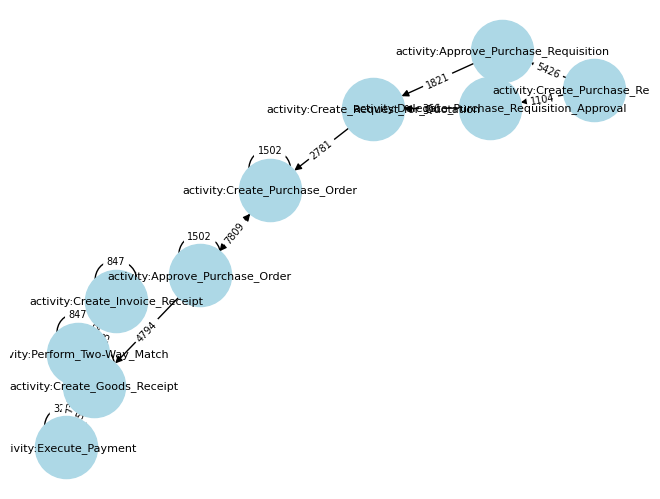

In [94]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G_global, seed=42)
edge_labels = {(u, v): d["frequency"] for u, v, d in G_global.edges(data=True)}

nx.draw(G_global, pos, with_labels=True, node_color="lightblue",
        node_size=2000, font_size=8, arrows=True)
nx.draw_networkx_edge_labels(G_global, pos, edge_labels=edge_labels, font_size=7)
plt.show()

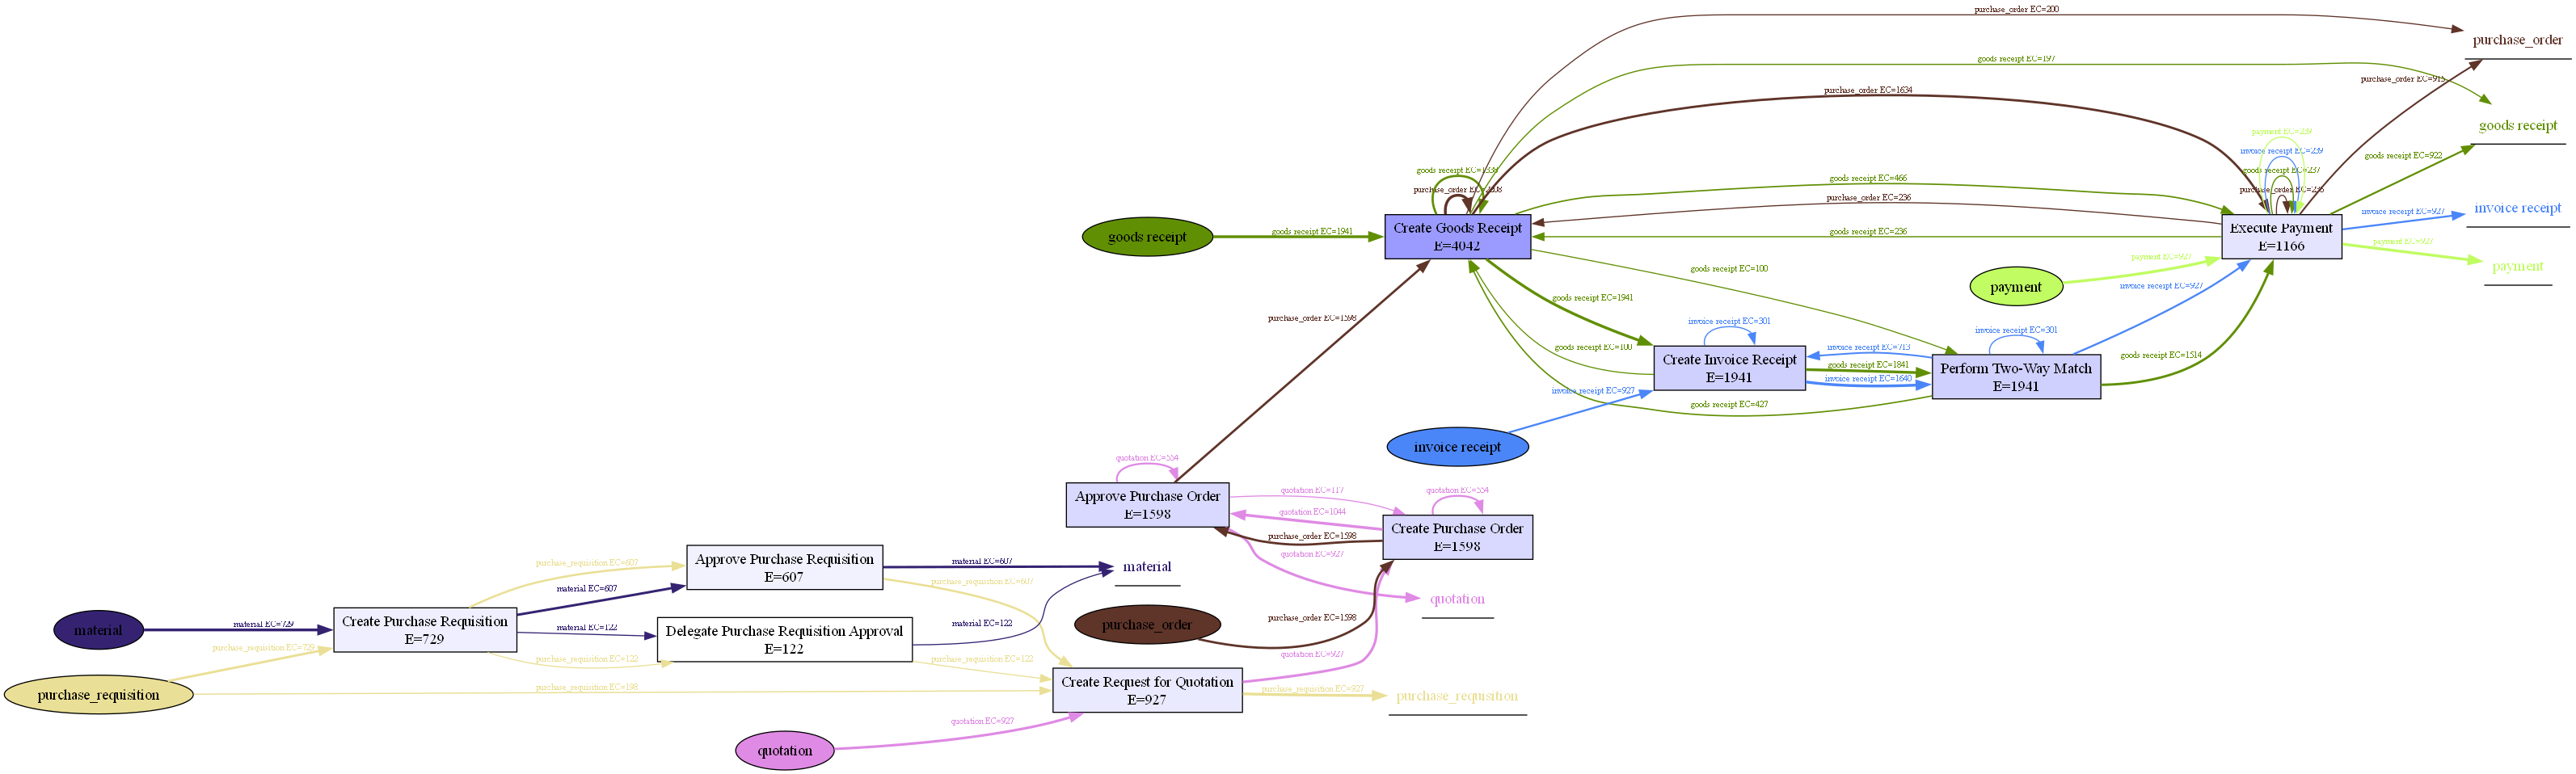

In [95]:
pm4py.view_ocdfg(ocdfg)

In [86]:
sample_ot = next(iter(ocdfg["edges"]))
arc_dict = ocdfg["edges"][sample_ot]
sample_inner_ot = next(iter(arc_dict))
inner = arc_dict[sample_inner_ot]
sample_key = next(iter(inner))
print(type(sample_key), sample_key)
print(type(inner[sample_key]), list(inner[sample_key])[:2])

<class 'tuple'> ('Create Purchase Requisition', 'Approve Purchase Requisition')
<class 'set'> [('event:14117', 'event:14322'), ('event:17236', 'event:17280')]


In [78]:
import networkx as nx
import matplotlib.pyplot as plt

import networkx as nx

def ocdfg_to_networkx(ocdfg):
    G = nx.MultiDiGraph()

    # 1. Add Activities as nodes
    activities = ocdfg.get("activities", [])
    for act in activities:
        if isinstance(act, str):
            G.add_node(act, type="activity")

    # 2. Add Edges based on your specific nested structure
    # Based on your print: ocdfg["edges"] is a dict_items list
    edge_data = ocdfg.get("edges", {})

    # Loop 1: Object Type (e.g., 'purchase_requisition')
    for obj_type, arcs_dict in edge_data.items():
        
        # Loop 2: The actual activity pairs inside that object type
        for activity_pair, event_set in arcs_dict.items():
            print(activity_pair)  # Debug print to understand the structure
            # Now we can safely unpack the two activities
            act1, act2 = activity_pair
            
            # Skip start/end markers
            if act1 is None or act2 is None:
                continue 
            
            # The weight is the number of event pairs in the set
            weight = len(event_set) if isinstance(event_set, set) else 1

            G.add_edge(
                act1, 
                act2, 
                object_type=obj_type, 
                weight=weight
            )

    return G

G_global = ocdfg_to_networkx(ocdfg)
#print(f"[Global graph] {G_global.number_of_nodes()} activity nodes, "   f"{G_global.number_of_edges()} DFG edges.")
print(G_global.edges(data=True))

purchase_requisition


ValueError: too many values to unpack (expected 2)

C:\Users\jorde\AppData\Local\Temp\ipykernel_8956\3840186572.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


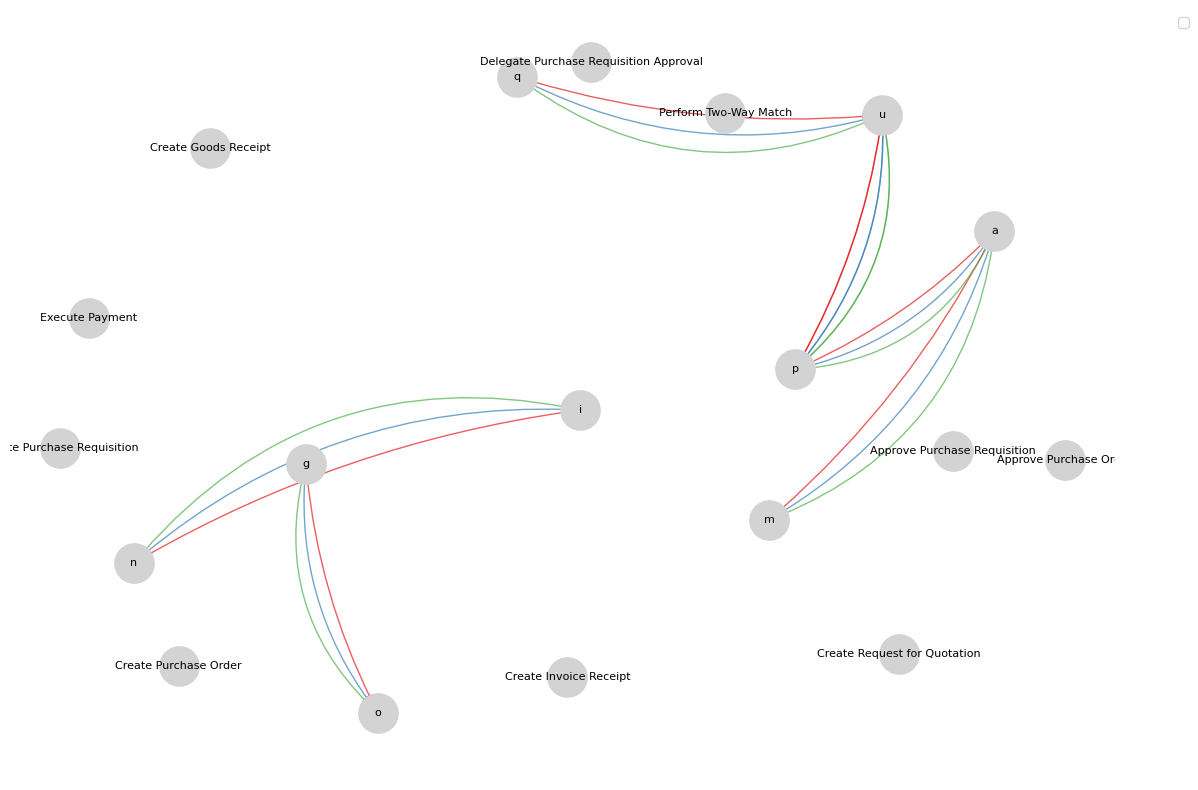

In [77]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_colored(G):
    # 1. Create layout graph H and Ensure ALL nodes from G are in H
    H = nx.DiGraph()
    H.add_nodes_from(G.nodes()) # <--- THIS FIXES THE "NO POSITION" ERROR

    for u, v, d in G.edges(data=True):
        # pm4py OCDFG weights are often sets of IDs
        w = d.get("weight", 1)
        
        # Ensure we are working with sets to avoid the += error
        if not isinstance(w, set):
            w = {w}

        if H.has_edge(u, v):
            # Union the sets
            H[u][v]["weight_set"] = H[u][v]["weight_set"] | w
        else:
            H.add_edge(u, v, weight_set=w)

    # 2. Convert set weights to integers for the layout algorithm
    for u, v, d in H.edges(data=True):
        d["weight"] = len(d["weight_set"])

    # 3. Calculate positions (now guaranteed to have all nodes)
    pos = nx.spring_layout(H, k=1, iterations=50)

    plt.figure(figsize=(12, 8))

    # 4. Draw nodes and labels
    nx.draw_networkx_nodes(G, pos, node_size=800, node_color="lightgrey")
    nx.draw_networkx_labels(G, pos, font_size=8)

    # 5. Group and draw edges by object type
    edge_types = {}
    # Note: MultiDiGraph needs 'keys=True' to iterate correctly
    for u, v, k, d in G.edges(keys=True, data=True):
        edge_types.setdefault(d["object_type"], []).append((u, v))

    colors = ["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00"]

    for i, (obj_type, edges) in enumerate(edge_types.items()):
        # Add a slight arc so overlapping object types are visible
        arc = 0.1 * (i + 1)
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges,
            edge_color=colors[i % len(colors)],
            label=obj_type,
            connectionstyle=f"arc3,rad={arc}",
            arrows=True,
            alpha=0.7
        )

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.axis("off")
    plt.tight_layout()
    plt.show()
visualize_colored(G_global)

In [45]:
import pm4py

ocdfg = pm4py.discover_ocdfg(ocel)
G_global = nx.DiGraph()

activities = set(ocdfg["activities"])

# --- 1. Build activity → object types mapping ---
activity_obj_types = {act: set() for act in activities}

for src_act, tgt_dict in ocdfg["edges"].items():
    if src_act not in activities:
        continue  # skip metadata like "event_couples"

    for tgt_act, type_freqs in tgt_dict.items():
        if tgt_act not in activities:
            continue

        for obj_type in type_freqs.keys():
            activity_obj_types[src_act].add(obj_type)
            activity_obj_types[tgt_act].add(obj_type)

# --- 2. Activity nodes ---
for act in activities:
    node_id = f"activity:{act.replace(' ', '_')}"
    G_global.add_node(
        node_id,
        entity_type="Activity",
        activity=act,
        object_types=list(activity_obj_types.get(act, [])),
    )

# --- 3. DFG edges ---
perf = ocdfg.get("edges_performance", {})

for src_act, tgt_dict in ocdfg["edges"].items():
    print(src_act, tgt_dict)
    if src_act not in activities:
        continue

    for tgt_act, type_freqs in tgt_dict.items():
        if tgt_act not in activities:
            continue

        total_freq = sum(type_freqs.values())
        if total_freq < 0:
            continue

        src_id = f"activity:{src_act.replace(' ', '_')}"
        tgt_id = f"activity:{tgt_act.replace(' ', '_')}"

        # Performance handling
        all_durations = []
        perf_entry = perf.get((src_act, tgt_act), {})

        for type_durs in perf_entry.values():
            all_durations.extend(type_durs)

        median_dur = statistics.median(all_durations) if all_durations else None

        G_global.add_edge(
            src_id, tgt_id,
            label="DFG_FOLLOWS",
            frequency=total_freq,
            median_duration_s=median_dur,
            per_type_freq=dict(type_freqs),
        )

print(f"[Global graph] {G_global.number_of_nodes()} activity nodes, "
      f"{G_global.number_of_edges()} DFG edges.")

event_couples {'purchase_requisition': {('Create Purchase Requisition', 'Approve Purchase Requisition'): {('event:14117', 'event:14322'), ('event:17236', 'event:17280'), ('event:27031', 'event:27037'), ('event:23001', 'event:23121'), ('event:28572', 'event:28788'), ('event:93', 'event:167'), ('event:449', 'event:482'), ('event:5720', 'event:5916'), ('event:4659', 'event:4876'), ('event:16950', 'event:17111'), ('event:24590', 'event:24715'), ('event:7962', 'event:7999'), ('event:10280', 'event:10357'), ('event:1877', 'event:2045'), ('event:5959', 'event:6114'), ('event:26370', 'event:26382'), ('event:12817', 'event:12874'), ('event:10300', 'event:10575'), ('event:16945', 'event:17012'), ('event:27355', 'event:27571'), ('event:4663', 'event:4800'), ('event:27630', 'event:27734'), ('event:20752', 'event:20763'), ('event:26971', 'event:27004'), ('event:7824', 'event:7862'), ('event:12012', 'event:12212'), ('event:19289', 'event:19322'), ('event:4288', 'event:4345'), ('event:383', 'event:44

In [37]:
import pm4py

ocdfg = pm4py.discover_ocdfg(ocel)
G_global = nx.DiGraph()

activities = set(ocdfg["activities"])
edges = ocdfg["edges"]["event_couples"]

# --- 1. Build activity → object types mapping ---
activity_obj_types = {act: set() for act in activities}

for (src_act, tgt_act), type_freqs in edges.items():
    for obj_type in type_freqs.keys():
        activity_obj_types[src_act].add(obj_type)
        activity_obj_types[tgt_act].add(obj_type)

# --- 2. Activity nodes ---
for act in activities:
    node_id = f"activity:{act.replace(' ', '_')}"
    G_global.add_node(
        node_id,
        entity_type="Activity",
        activity=act,
        object_types=list(activity_obj_types.get(act, [])),
    )

# --- 3. DFG edges ---
perf = ocdfg.get("edges_performance", {})

for (src_act, tgt_act), type_freqs in edges.items():

    total_freq = sum(type_freqs.values())
    if total_freq < 0:   # effectively no filtering
        continue

    src_id = f"activity:{src_act.replace(' ', '_')}"
    tgt_id = f"activity:{tgt_act.replace(' ', '_')}"

    # Performance handling
    all_durations = []
    perf_entry = perf.get((src_act, tgt_act), {})

    for type_durs in perf_entry.values():
        all_durations.extend(type_durs)

    median_dur = statistics.median(all_durations) if all_durations else None

    G_global.add_edge(
        src_id, tgt_id,
        label="DFG_FOLLOWS",
        frequency=total_freq,
        median_duration_s=median_dur,
        per_type_freq=dict(type_freqs),
    )

print(f"[Global graph] {G_global.number_of_nodes()} activity nodes, "
      f"{G_global.number_of_edges()} DFG edges.")

ValueError: too many values to unpack (expected 2)

In [ ]:
events = ocel.events
objects = ocel.objects
e2o = ocel.relations
e2e = ocel.e2e
o2o = ocel.o2o

#print(o2o["ocel:qualifier"].value_counts())
#print(e2e["ocel:qualifier"].value_counts())
print(e2e.value_counts())

ocel:oid         ocel:oid_2          ocel:qualifier                  
goods receipt:0  payment:2           goods_receipt_pm                    1
                 purchase_order:3    Good Receipts of Purchase Order     1
goods receipt:1  invoice receipt:2   Invoice Receipt of Goods Receipt    1
                 payment:2           goods_receipt_pm                    1
                 purchase_order:3    Good Receipts of Purchase Order     1
                                                                        ..
quotation:99     material:248        Materials of Quotation              1
                 material:249        Materials of Quotation              1
                 purchase_order:164  Purchase Order of Quotation         1
                 purchase_order:165  Purchase Order of Quotation         1
                 purchase_order:166  Purchase Order of Quotation         1
Name: count, Length: 16757, dtype: int64
